<a href="https://colab.research.google.com/github/trialdyk/marchine-learning/blob/main/JS06/JS06_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 2 - Klasifikasi SVM dengan Data Dummy Non-Linier

Pemanfaatan Support Vector Machine (SVM) dengan *kernel trick* (RBF) untuk klasifikasi data distribusi non-linier.

## Langkah 1 - Ilustrasi Data Non-Linier

### Langkah 1a - Import Library

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

### Langkah 1b - Buat Kembali Fungsi Plotting

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data
def plot_svc_decision_function(model, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

### Langkah 1c - Buat Data Dummy Non-Linier

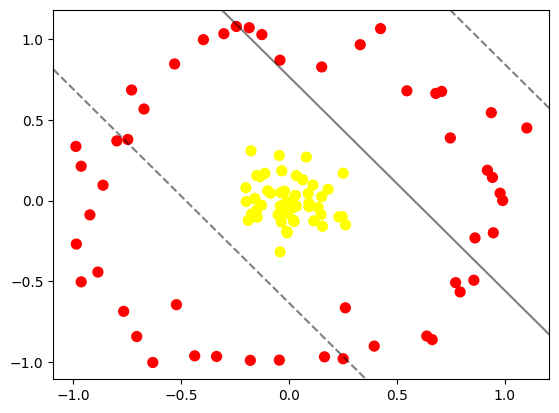

In [3]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

### Proyeksi Berbasis Radial

In [4]:
r = np.exp(-(X**2).sum(1))

### Visualisasi Model 3D

In [5]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

# Catatan: typo modul 'azip' dikoreksi menjadi 'azim' agar parameter fungsi sesuai
interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azim=(-180, 180), X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-1.35417403e-02, -7.99018369e-02],
       [ 7.71894649e-01, -5.08782813e-01],
       [ 9.18919552e-02, -1.63814219e-02],
       [-7.67158594e-01, -6.86651020e-01],
       [ 2.25603291e-02, -1.29623787e-01],
       [-1.28280100e-01, -2.80058040e-02],
       [-3.66725014e-02, -1.32537602e-01],
       [-6.31855201e-01, -1.00364292e+00],
       [ 2.91853226e-02,  3.33697433e-02],
       [ 5.45978160e-01,  6.80770573e-01],
       [ 1.54307527e-01, -1.59314872e-01],
       [-9.91707085e-02,  6.04952891e-02],
       [ 6.29415093e-02,  1.29127955e-01],
       [ 7.07024323e-01,  6.76852546e-01],
       [-8.62776166e-01,  9.55154810e-02],
       [ 2.30865156e-01, -1.01168142e-01],
       [-2.00693386e-01,  7.98059713e-02],
       [-8.52663758e-03, -1.99878597e-01],
       [ 1.48004361e-01, -8.64986655e-02],
       [ 2.60651189e-01, -6.64702144e-01],
       [ 7.47261688e-01,  3.88423635e-01],
       [ 9.89972470e-01,  5.74168266e-04],
       [-1.12808016e-02, -4.83261273e-03],
       [ 7.97118591e-02,  2.69628770e-01],
       [ 3.94499325e-01, -9.02134200e-01],
       [ 1.34048864e-01, -4.21844914e-02],
       [-8.86582815e-01, -4.43046891e-01],
       [-1.12208127e-01,  1.68955914e-01],
       [ 8.56404684e-01, -4.93727129e-01],
       [ 3.37098658e-02,  1.54798700e-01],
       [-5.31050142e-01,  8.47114901e-01],
       [-7.06445745e-01, -8.42682522e-01],
       [-8.54194597e-02,  4.51885471e-02],
       [ 1.10180900e+00,  4.50221773e-01],
       [ 7.92750169e-01, -5.66211545e-01],
       [ 2.50451281e-01,  1.69562148e-01],
       [-2.14389702e-02,  5.84736121e-02],
       [-9.63898839e-01, -5.03788972e-01],
       [ 8.07046718e-03, -5.33957767e-02],
       [-1.79935639e-01, -9.90325716e-01],
       [ 3.01581925e-02, -3.23418382e-02],
       [ 4.23775794e-01,  1.06627351e+00],
       [ 9.17830325e-02, -3.78493246e-02],
       [ 9.42635915e-01,  1.43628519e-01],
       [-7.47876985e-01,  3.78904383e-01],
       [-9.88547769e-01,  3.35966906e-01],
       [-1.89829758e-01, -1.23199618e-01],
       [ 6.38119928e-01, -8.39783178e-01],
       [ 2.46229495e-01, -9.94104710e-02],
       [-9.23508335e-01, -8.84660196e-02],
       [ 3.36705844e-02, -3.41239609e-02],
       [ 1.80597976e-01,  7.01465531e-02],
       [-7.98693842e-01,  3.70252512e-01],
       [-1.50491282e-01,  1.55526466e-01],
       [ 1.64024322e-01, -9.68700860e-01],
       [-1.76795544e-01,  3.08631414e-01],
       [ 1.14349202e-01, -1.26376326e-01],
       [-2.44826748e-01,  1.07950637e+00],
       [-5.13691649e-02, -8.72059177e-02],
       [-5.22575406e-01, -6.45231139e-01],
       [ 1.50973391e-01,  8.28613034e-01],
       [-3.97420038e-01,  9.97805154e-01],
       [-1.15484207e-02, -1.90288549e-01],
       [-1.59057021e-01,  1.35690862e-02],
       [-1.34598838e-01,  1.49017759e-01],
       [ 9.19181738e-01,  1.87905684e-01],
       [-3.36314483e-01, -9.66326041e-01],
       [-3.84520067e-02,  4.90266175e-02],
       [-1.49995501e-01, -5.73192355e-02],
       [-6.72849134e-01,  5.67798166e-01],
       [ 1.10706428e-01,  9.63645986e-02],
       [ 9.37270749e-01,  5.45108040e-01],
       [ 8.61674936e-01, -2.31614170e-01],
       [ 6.80004353e-01,  6.64543513e-01],
       [-1.85132200e-01,  1.07183239e+00],
       [-1.74028395e-01, -8.29056624e-02],
       [ 8.86151098e-02,  4.47549784e-02],
       [-3.40048852e-02,  1.84647652e-01],
       [ 2.50359143e-01, -9.80399783e-01],
       [-4.37810432e-01, -9.62423906e-01],
       [-9.64055899e-01,  2.13043432e-01],
       [-3.02646633e-01,  1.03461389e+00],
       [-7.30331485e-01,  6.85757103e-01],
       [ 3.29455729e-01,  9.66626685e-01],
       [ 1.37944804e-02, -5.82873362e-03],
       [ 1.50882029e-01,  2.47580420e-02],
       [-1.26248631e-01,  1.02935510e+00],
       [-4.55615463e-02,  2.79781975e-01],
       [ 9.78098848e-01,  4.57425122e-02],
       [ 9.46539273e-01, -1.99665556e-01],
       [-4.53124139e-02, -9.89141996e-01],
       [ 6.63207363e-01, -8.61753277e-01

## Langkah 2 - Fitting Model

In [6]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

### Plot Decision Boundaries dari Kernel RBF

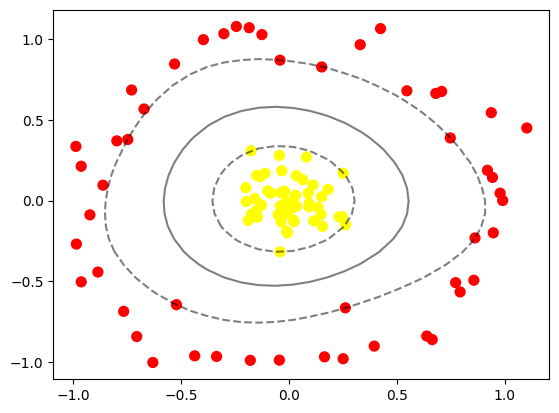

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=300, lw=1, facecolors='none')